<a href="https://colab.research.google.com/github/Nachos-mic/Lung_CT_Diagnostic_ML/blob/main/Lung_Diagnostics_FULL_SLICE_FOCAL_FINAL_RETR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Biblioteki


In [1]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 128.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.5 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import copy
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from torch.utils.data import WeightedRandomSampler
import optuna
from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix, accuracy_score
import random
import torch.nn.functional as F
import cv2
import json
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


MERGED_STAGE_TO_LABEL = {
    'I': 0,
    'II': 1,
    'IIIa': 2,
    'IIIb': 2,
    'III': 2,
}
LABEL_TO_MERGED_STAGE = {
    0: 'I',
    1: 'II',
    2: 'III',
}
NUM_CLASSES = len(LABEL_TO_MERGED_STAGE)


def merge_stage_label(value):
    if pd.isna(value):
        raise ValueError('Missing stage or label value')

    if isinstance(value, str):
        normalized = value.strip()
        if normalized in MERGED_STAGE_TO_LABEL:
            return MERGED_STAGE_TO_LABEL[normalized]
        return 2 if normalized == 'III' else int(normalized)

    return 2 if int(value) == 3 else int(value)


Rozpakowanie danych do dysku (jednorazowe)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

#Tworzenie folderu z danymi
!mkdir -p /content/dataset
!unzip -q "/content/drive/MyDrive/lung_dataset.zip" -d "/content/dataset"
print("Dane rozpakowane pomyślnie!")

Mounted at /content/drive
Dane rozpakowane pomyślnie!


EDA dla datasetu - statystyki klas i wizualizacja przykładowych slice'ów

/tmp/ipykernel_10919/566853590.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')


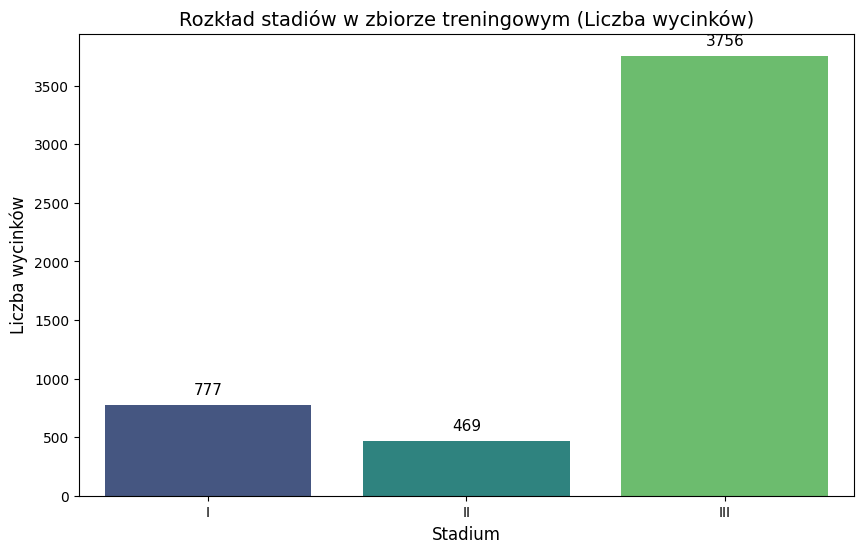


--- Przykładowe wycinki dla poszczególnych klas ---


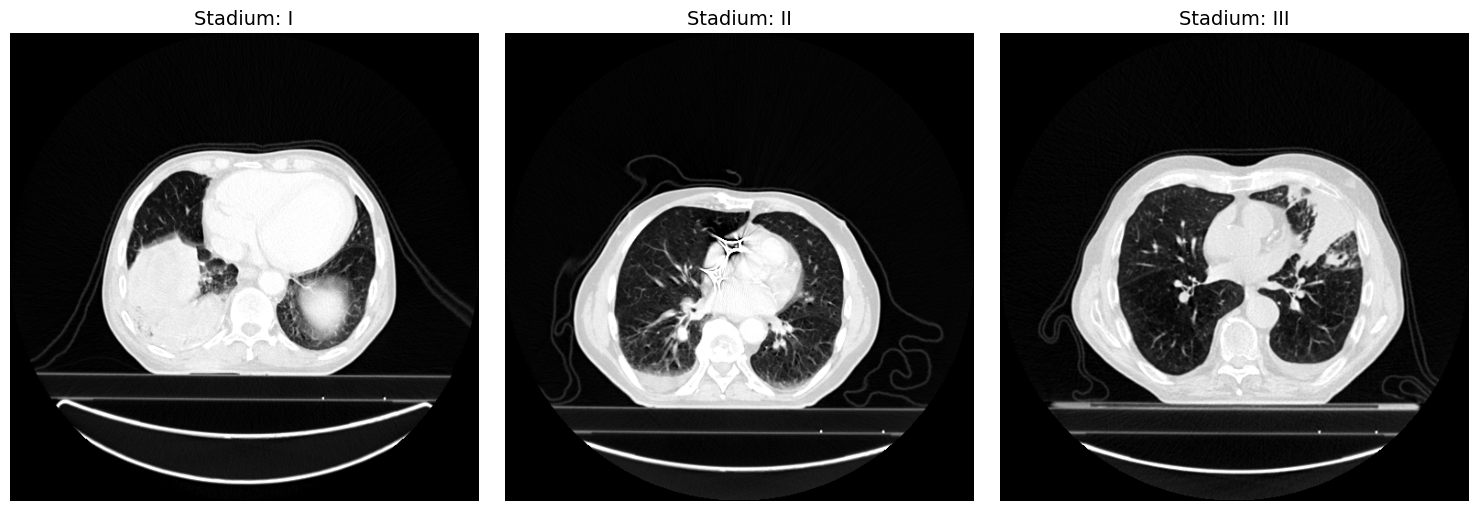

In [5]:
# Ścieżka do wypakowanego pliku train.csv
TRAIN_CSV = '/content/dataset/train.csv'

df_train = pd.read_csv(TRAIN_CSV)
df_train['merged_stage'] = df_train['original_stage'].replace({'IIIa': 'III', 'IIIb': 'III'})

# Statystyki klas w zbiorze treningowym
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='merged_stage', order=['I', 'II', 'III'], palette='viridis')
plt.title('Rozkład stadiów w zbiorze treningowym (Liczba wycinków)', fontsize=14)
plt.xlabel('Stadium', fontsize=12)
plt.ylabel('Liczba wycinków', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

# Wizualizacja przykładowych zdjęć dla każdej z 3 klas po połączeniu IIIa i IIIb
print("\n--- Przykładowe wycinki dla poszczególnych klas ---")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
stages = ['I', 'II', 'III']

for i, stage in enumerate(stages):
    sample_img_path = df_train[df_train['merged_stage'] == stage].iloc[0]['image_path']

    clean_path = sample_img_path.replace('\\', '/')
    filename = os.path.basename(clean_path)

    colab_img_path = os.path.join('/content/dataset/data_2d_full_slices', filename)

    img = Image.open(colab_img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Stadium: {stage}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

EDA dla datasetu - demografia pacjentów, typy histologiczne i podział slice'ów pomiędzy pacjentami

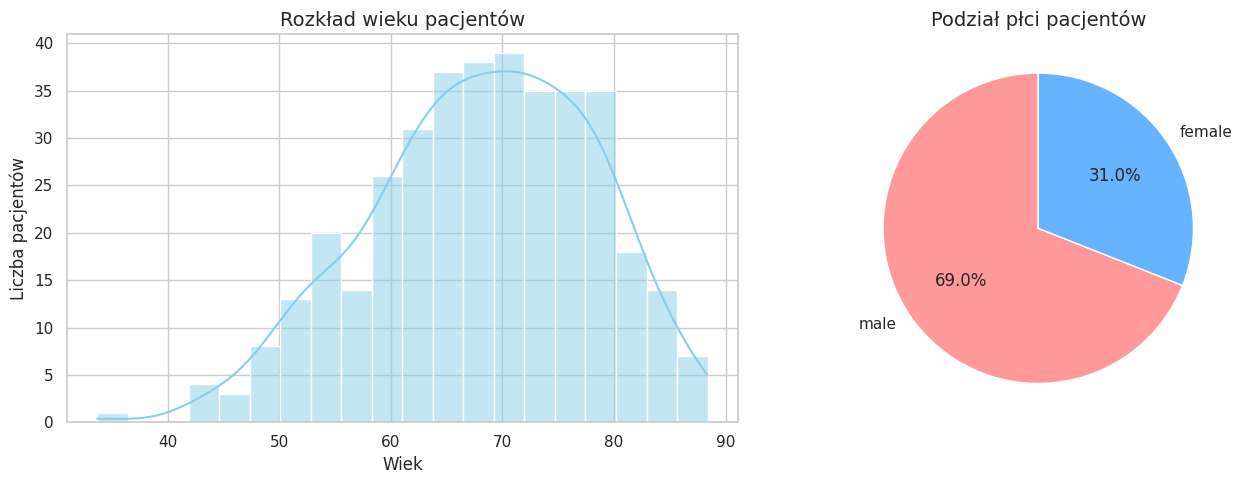

/tmp/ipykernel_10919/537504310.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')


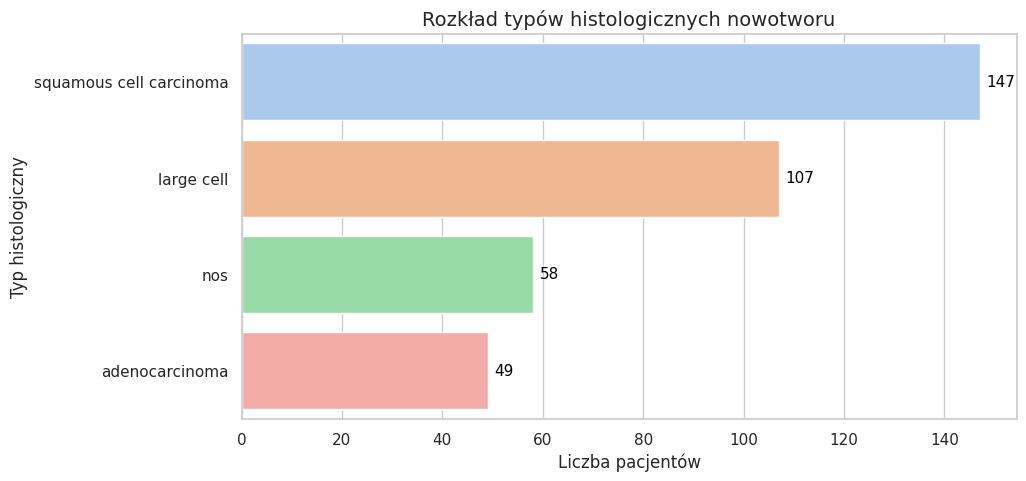

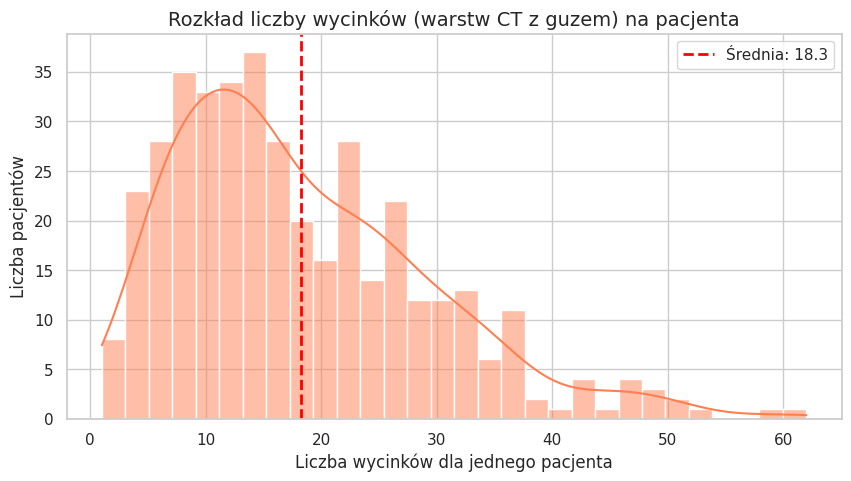

Całkowita liczba uwzględnionych pacjentów: 400
Średni wiek pacjenta: 68.1 lat (Min: 34, Max: 88)
Średnia liczba wycinków na pacjenta: 18.3
Pacjent z najmniejszą liczbą wycinków ma ich: 1
Pacjent z największą liczbą wycinków ma ich: 62


In [6]:

MASTER_CSV = r"/content/dataset/master_dataset.csv"
CLINICAL_CSV = r"/content/dataset/NSCLC-Radiomics-Lung1.clinical-data.csv"

df_master = pd.read_csv(MASTER_CSV)
df_clinical = pd.read_csv(CLINICAL_CSV)

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()
df_master['patient_id'] = df_master['patient_id'].astype(str).str.strip()

df_merged = df_master[['patient_id']].drop_duplicates().merge(
    df_clinical, left_on='patient_id', right_on='PatientID', how='inner'
)

sns.set_theme(style="whitegrid")

# Demografia (Wiek i Płeć)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(data=df_merged, x='age', bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Rozkład wieku pacjentów', fontsize=14)
axes[0].set_xlabel('Wiek', fontsize=12)
axes[0].set_ylabel('Liczba pacjentów', fontsize=12)

gender_col = 'gender' if 'gender' in df_merged.columns else 'Gender' if 'Gender' in df_merged.columns else None

if gender_col:
    gender_counts = df_merged[gender_col].value_counts()
    axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
                startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Podział płci pacjentów', fontsize=14)

plt.tight_layout()
plt.show()

# Typy Histologiczne
histology_col = 'Histology' if 'Histology' in df_merged.columns else 'histology' if 'histology' in df_merged.columns else None

if histology_col:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=df_merged, y=histology_col, order=df_merged[histology_col].value_counts().index, palette='pastel')
    plt.title('Rozkład typów histologicznych nowotworu', fontsize=14)
    plt.xlabel('Liczba pacjentów', fontsize=12)
    plt.ylabel('Typ histologiczny', fontsize=12)

    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0), textcoords='offset points')
    plt.show()

# Rozkład liczby warstw (wycinków) na pacjenta
plt.figure(figsize=(10, 5))
slices_per_patient = df_master.groupby('patient_id').size()

sns.histplot(slices_per_patient, bins=30, kde=True, color='coral')
plt.title('Rozkład liczby wycinków (warstw CT z guzem) na pacjenta', fontsize=14)
plt.xlabel('Liczba wycinków dla jednego pacjenta', fontsize=12)
plt.ylabel('Liczba pacjentów', fontsize=12)

mean_slices = slices_per_patient.mean()
plt.axvline(mean_slices, color='red', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_slices:.1f}')
plt.legend()
plt.show()

print(f"Całkowita liczba uwzględnionych pacjentów: {len(df_merged)}")
print(f"Średni wiek pacjenta: {df_merged['age'].mean():.1f} lat (Min: {df_merged['age'].min():.0f}, Max: {df_merged['age'].max():.0f})")
print(f"Średnia liczba wycinków na pacjenta: {mean_slices:.1f}")
print(f"Pacjent z najmniejszą liczbą wycinków ma ich: {slices_per_patient.min()}")
print(f"Pacjent z największą liczbą wycinków ma ich: {slices_per_patient.max()}")

# PROTO - dodanie wieku i innych cech:



In [7]:
# Wczytanie i przygotowanie metadanych klinicznych
df_clinical = pd.read_csv('/content/dataset/NSCLC-Radiomics-Lung1.clinical-data.csv')

df_clinical['PatientID'] = df_clinical['PatientID'].astype(str).str.strip()

# Wczytanie pacjentów tylko ze zbioru treningowego
df_train_for_leak = pd.read_csv('/content/dataset/train.csv')
train_patient_ids = df_train_for_leak['patient_id'].astype(str).str.strip().unique()

train_clinical = df_clinical[df_clinical['PatientID'].isin(train_patient_ids)]
age_mean = train_clinical['age'].mean()
age_std = train_clinical['age'].std()

# Aplikacja normalizacji na WSZYSTKICH pacjentów (Train, Val, Test) używając parametrów treningowych
df_clinical['age_norm'] = (df_clinical['age'] - age_mean) / age_std

df_clinical['gender_bin'] = df_clinical['gender'].map({'male': 0.0, 'female': 1.0}).fillna(0.0)
clinical_features = df_clinical[['PatientID', 'age_norm', 'gender_bin']]

Preprocessing do ResNet

In [8]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

# Przekształcenia dla zbioru treningowego z augumentacją danych
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),  # <-- musi być po ToTensor
])

# Przekształcenia dla zbiorów walidacyjnych i testowych
val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach.")

Transforms gotowe! Sieć będzie pracować na znormalizowanych tensorach.


Klasa Dataset

In [9]:
class LungCancerHybridDataset(Dataset):
    def __init__(self, csv_file, clinical_df, root_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

        # Merge z danymi klinicznymi
        self.data_frame = self.data_frame.merge(
            clinical_df[['PatientID', 'age_norm', 'gender_bin']],
            left_on='patient_id', right_on='PatientID', how='left'
        )

        self.data_frame['age_norm'] = self.data_frame['age_norm'].fillna(0.0)
        self.data_frame['gender_bin'] = self.data_frame['gender_bin'].fillna(0.0)

        # Mapowanie etykiet
        label_col = 'original_stage' if 'original_stage' in self.data_frame.columns else 'label'
        self.data_frame['merged_label'] = self.data_frame[label_col].apply(merge_stage_label)

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]

        # Obraz
        filename = os.path.basename(row['image_path'].replace('\\', '/'))
        img_path = os.path.join(self.root_dir, filename)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Dane kliniczne (Wiek, Płeć)
        clinical_vec = torch.tensor([row['age_norm'], row['gender_bin']], dtype=torch.float32)

        # Etykieta
        label = int(row['merged_label'])

        return image, clinical_vec, label



DataLoaders i WeightedSampler


In [10]:
from sklearn.utils.class_weight import compute_class_weight
IMG_DIR_COLAB = '/content/dataset/data_2d_full_slices'

# Tworzenie instancji hybrydowych datasetów
train_dataset = LungCancerHybridDataset(csv_file='/content/dataset/train.csv',
                                        clinical_df=clinical_features,
                                        root_dir=IMG_DIR_COLAB,
                                        transform=train_transforms)

val_dataset = LungCancerHybridDataset(csv_file='/content/dataset/val.csv',
                                      clinical_df=clinical_features,
                                      root_dir=IMG_DIR_COLAB,
                                      transform=val_test_transforms)

test_dataset = LungCancerHybridDataset(csv_file='/content/dataset/test.csv',
                                       clinical_df=clinical_features,
                                       root_dir=IMG_DIR_COLAB,
                                       transform=val_test_transforms)

# Weighted Sampler - Balansowanie klas I, II, III
train_labels = train_dataset.data_frame['merged_label'].values
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = torch.from_numpy(class_weights[train_labels]).type(torch.DoubleTensor)

CT_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True , num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# OBLICZENIE WAG DLA FUNKCJI STRATY
# Używamy dokładnie tej nazwy kolumny, którą miałeś w samplerze: 'merged_label'
train_labels_for_loss = train_dataset.data_frame['merged_label'].values

computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_for_loss),
    y=train_labels_for_loss
)

print(f"\nWyliczone wagi klas dla Loss Function (I, II, III): {computed_weights}")

# Weryfikacja
sample_batch = next(iter(train_loader))
print(f"Batch obrazów: {sample_batch[0].shape}")
print(f"Batch danych klinicznych: {sample_batch[1].shape}") # Powinno być [32, 2]
print(f"Batch etykiet: {sample_batch[2].shape}")
print("\nDane gotowe do treningu hybrydowego!")


Wyliczone wagi klas dla Loss Function (I, II, III): [2.14586015 3.55508173 0.44391196]
Batch obrazów: torch.Size([32, 3, 224, 224])
Batch danych klinicznych: torch.Size([32, 2])
Batch etykiet: torch.Size([32])

Dane gotowe do treningu hybrydowego!


In [11]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, input, target):
        ce_loss = F.cross_entropy(input, target, weight=self.weight, reduction='none')
        pt      = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

Trening ResNet- 18

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")
if device.type == 'cpu':
    print("UWAGA: Trenujesz na procesorze! Zmień środowisko wykonawcze w Colabie na T4 GPU.")

class ResNetHybrid(nn.Module):
    def __init__(self, num_classes=3, hidden_units=512, dropout_rate=0.4):
        super(ResNetHybrid, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        num_ftrs = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs + 2, hidden_units),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_units, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, clinical):
        img_features = self.backbone(img)
        combined     = torch.cat((img_features, clinical), dim=1)
        return self.classifier(combined)

# Inicjalizacja modelu hybrydowego i odmrażanie warstw
# Model - bez zmian (ResNet-18, partial freezing)
# model = ResNetHybrid(num_classes=3, dropout_rate=0.4)

# for param in model.parameters():
#     param.requires_grad = False
# for param in model.backbone.layer3.parameters():
#     param.requires_grad = True
# for param in model.backbone.layer4.parameters():
#     param.requires_grad = True
# for param in model.classifier.parameters():
#     param.requires_grad = True

# model = model.to(device)

# train_labels  = train_dataset.data_frame['merged_label'].values
# class_counts  = np.bincount(train_labels)
# soft_weights  = 1.0 / np.sqrt(class_counts)
# soft_weights  = soft_weights / soft_weights.sum() * 3
# weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

# print(f"Soft wagi klas (I, II, III): {soft_weights.round(4)}")

# criterion = FocalLoss(gamma=1.25) #, weight=weights_tensor
# # criterion = torch.nn.CrossEntropyLoss(weight=weights_tensor)

# optimizer = optim.Adam([
#     {'params': model.backbone.layer3.parameters(), 'lr': 1e-6},
#     {'params': model.backbone.layer4.parameters(), 'lr': 5e-6},
#     {'params': model.classifier.parameters(),      'lr': 1e-3}
# ], weight_decay=1e-3)

# print("Setup: Focal Loss gotowy!")


Używane urządzenie: cuda


Pętla ucząca

In [14]:
# konfiguracja treninigu
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
best_auc = 0.0
best_f1 = 0.0
best_acc = 0.0
results_path = 'best_metrics.txt'

with open(results_path, 'w') as f:
    f.write("REKORDY MODELU HYBRYDOWEGO (NSCLC STAGING)\n")


history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_auc': [], 'val_auc': []
}

NUM_EPOCHS = 20

# --- KONFIGURACJA EARLY STOPPING ---
patience = 10
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'Epoka {epoch+1}/{NUM_EPOCHS}')

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        dataloader = train_loader if phase == 'train' else val_loader

        running_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []

        for inputs, clinical_data, labels in dataloader:
            inputs, clinical_data, labels = inputs.to(device), clinical_data.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs, clinical_data)
                probs = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            epoch_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            epoch_auc = 0.0

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc)
        history[f'{phase}_f1'].append(epoch_f1)
        history[f'{phase}_auc'].append(epoch_auc)

        print(f'{phase.upper()} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1: {epoch_f1:.4f} | AUC: {epoch_auc:.4f}')

        if phase == 'val':
            if epoch_acc > best_acc:
                best_acc = epoch_acc

            # Rejestrowanie rekordu AUC (bez zapisu modelu)
            if epoch_auc > best_auc:
                best_auc = epoch_auc
                print(f"*** Nowy rekord AUC: {best_auc:.4f} ***")

            # Zapis modelu i Early Stopping na podstawie F1
            if epoch_f1 > best_f1:
                best_f1 = epoch_f1
                torch.save(model.state_dict(), 'best_hybrid_f1.pth')
                print(f"*** Zapisano model (Nowy rekord F1: {best_f1:.4f}) ***")
                epochs_no_improve = 0  # Resetujemy licznik cierpliwości
            else:
                epochs_no_improve += 1

    # Sprawdzenie warunku Early Stopping po zakończeniu obu faz (train i val) w epoce
    if epochs_no_improve >= patience:
        print(f"\n[Early Stopping] Brak poprawy F1 od {patience} epok. Przerwano trening.")
        break

    print()

# Ewaluacja
print("\nRaport klasyfikacji")

# WAŻNE: Wczytujemy model zapisany na podstawie najlepszego wyniku F1
model.load_state_dict(torch.load('best_hybrid_f1.pth'))
model.eval()

final_preds, final_labels, final_probs = [], [], []

with torch.no_grad():
    for inputs, clinical_data, labels in val_loader:
        inputs, clinical_data = inputs.to(device), clinical_data.to(device)
        outputs = model(inputs, clinical_data)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        final_preds.extend(preds.cpu().numpy())
        final_labels.extend(labels.cpu().numpy())
        final_probs.extend(probs.cpu().numpy())

final_auc = roc_auc_score(final_labels, final_probs, multi_class='ovr', average='macro')
final_acc = accuracy_score(final_labels, final_preds)

print(f"\nOstateczny wynik AUC: {final_auc:.4f}")
print(f"Ostateczny wynik Acc: {final_acc:.4f}")
print(f"Referencyjny wynik z publikacji (RF): 0.881")
print("\nSzczegółowy raport klasyfikacji:")
print(classification_report(final_labels, final_preds, target_names=target_names))

cm = confusion_matrix(final_labels, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek (Final AUC: {final_auc:.4f} | Acc: {final_acc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

# Soft-voting na poziomie pacjentów

df_val_results = val_dataset.data_frame.copy()

df_val_results['prob_I'] = [p[0] for p in final_probs]
df_val_results['prob_II'] = [p[1] for p in final_probs]
df_val_results['prob_III'] = [p[2] for p in final_probs]
df_val_results['true_label'] = final_labels

patient_level_df = df_val_results.groupby('patient_id').agg({
    'prob_I': 'mean',
    'prob_II': 'mean',
    'prob_III': 'mean',
    'true_label': 'first'
}).reset_index()

patient_probs = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
patient_preds = np.argmax(patient_probs, axis=1)
patient_true = patient_level_df['true_label'].values

patient_acc = accuracy_score(patient_true, patient_preds)
patient_auc = roc_auc_score(patient_true, patient_probs, multi_class='ovr', average='macro')

print(" Wyniki soft-voting na zbiorze walidacyjnym")
print(" (Agregacja 2D -> 3D za pomocą Soft Voting)")
print(f"PATIENT AUC: {patient_auc:.4f} (Wynik referencyjny z publikacji: 0.881)")
print(f"PATIENT ACC: {patient_acc:.4f}")
print(classification_report(patient_true, patient_preds, target_names=target_names))

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek - Pacjenci (Patient AUC: {patient_auc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.show()

Epoka 1/20
TRAIN Loss: 0.3842 | Acc: 0.7527 | F1: 0.3695 | AUC: 0.6876
VAL Loss: 0.4363 | Acc: 0.7361 | F1: 0.3787 | AUC: 0.6350
*** Nowy rekord AUC: 0.6350 ***
*** Zapisano model (Nowy rekord F1: 0.3787) ***

Epoka 2/20
TRAIN Loss: 0.3478 | Acc: 0.7675 | F1: 0.4404 | AUC: 0.7480
VAL Loss: 0.4304 | Acc: 0.6943 | F1: 0.4235 | AUC: 0.6644
*** Nowy rekord AUC: 0.6644 ***
*** Zapisano model (Nowy rekord F1: 0.4235) ***

Epoka 3/20
TRAIN Loss: 0.3359 | Acc: 0.7771 | F1: 0.4693 | AUC: 0.7646
VAL Loss: 0.3814 | Acc: 0.7412 | F1: 0.4131 | AUC: 0.7074
*** Nowy rekord AUC: 0.7074 ***

Epoka 4/20
TRAIN Loss: 0.3092 | Acc: 0.7799 | F1: 0.4775 | AUC: 0.8010
VAL Loss: 0.3961 | Acc: 0.7575 | F1: 0.3348 | AUC: 0.6936

Epoka 5/20
TRAIN Loss: 0.3131 | Acc: 0.7843 | F1: 0.4946 | AUC: 0.7907
VAL Loss: 0.4488 | Acc: 0.7566 | F1: 0.3059 | AUC: 0.7213
*** Nowy rekord AUC: 0.7213 ***

Epoka 6/20
TRAIN Loss: 0.3155 | Acc: 0.7827 | F1: 0.4792 | AUC: 0.7891
VAL Loss: 0.3920 | Acc: 0.7609 | F1: 0.3398 | AUC: 0.70

KeyboardInterrupt: 

Krzywa uczenia i straty

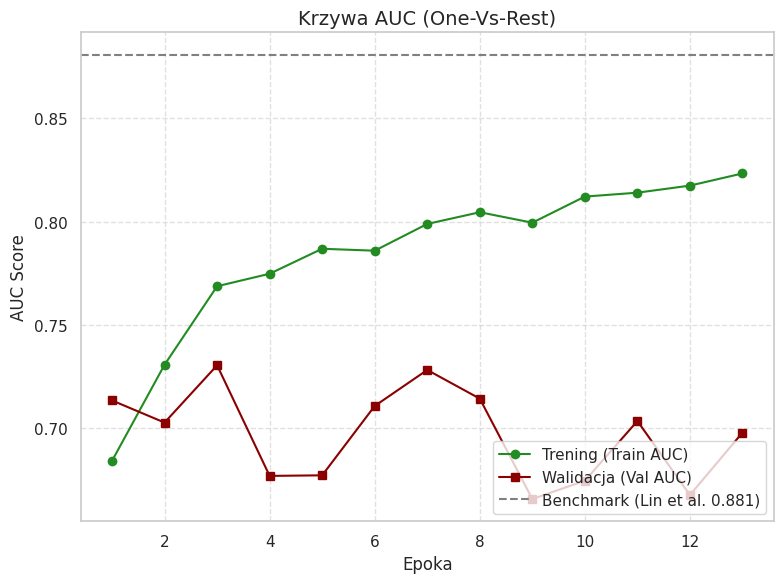

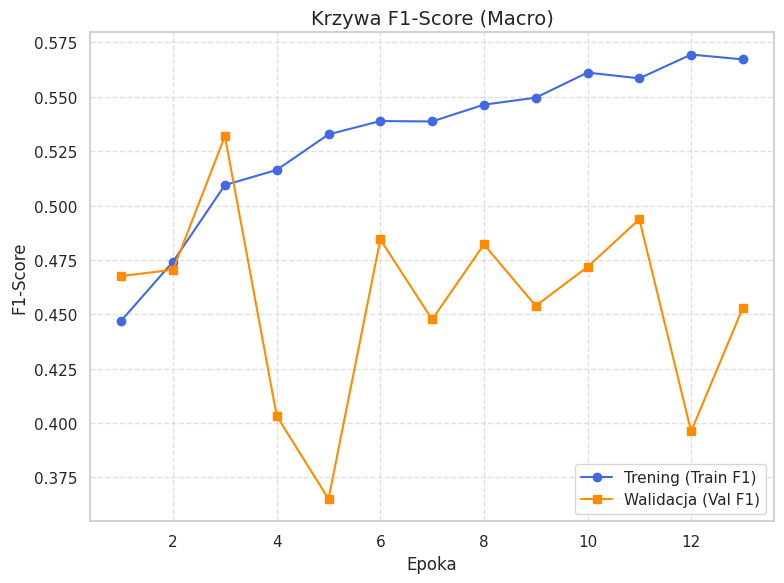

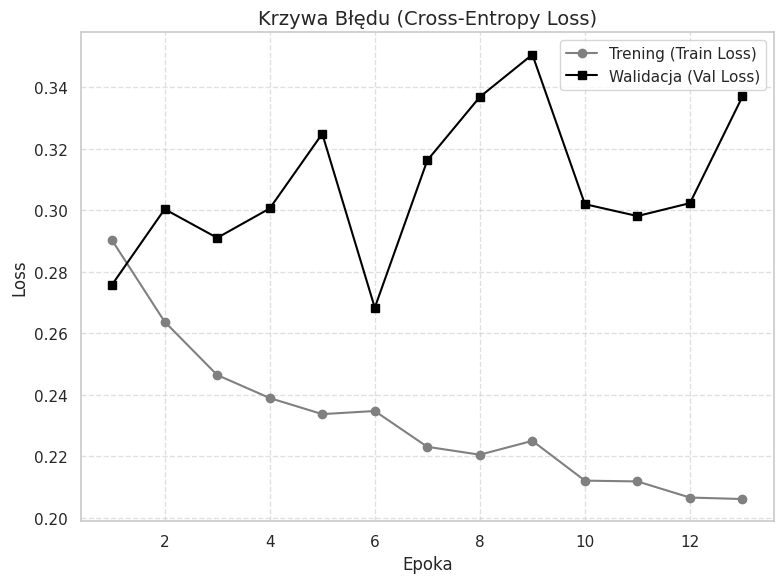

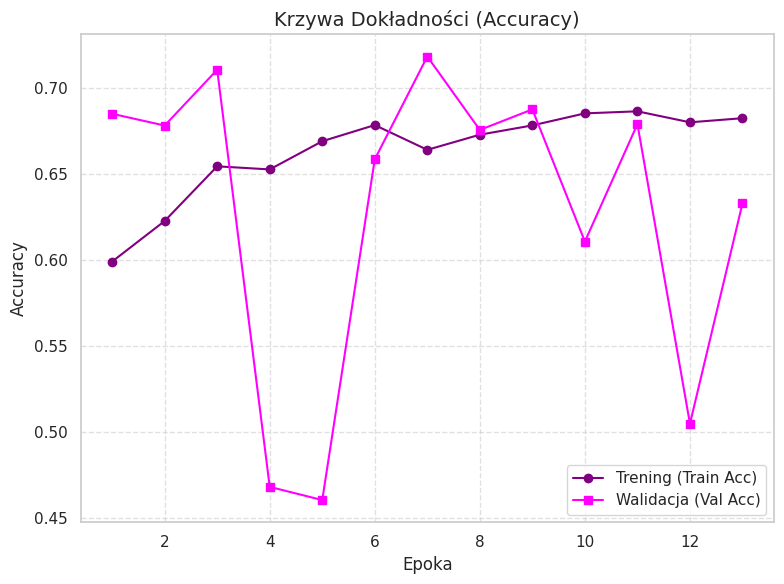

In [ ]:
epochs_range = range(1, len(history['train_f1']) + 1)

#  AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_auc', [0]*len(epochs_range)), label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history.get('val_auc', [0]*len(epochs_range)), label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC (One-Vs-Rest)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_auc.png', dpi=300, bbox_inches='tight')
plt.show()


# F1-Score (Macro Average)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# Funkcja błędu (Loss)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_loss', [0]*len(epochs_range)), label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history.get('val_loss', [0]*len(epochs_range)), label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu (Cross-Entropy Loss)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy (Dokładność)
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history.get('train_acc', [0]*len(epochs_range)), label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history.get('val_acc', [0]*len(epochs_range)), label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy)', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/hybrid_model_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

Grad-Cam

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


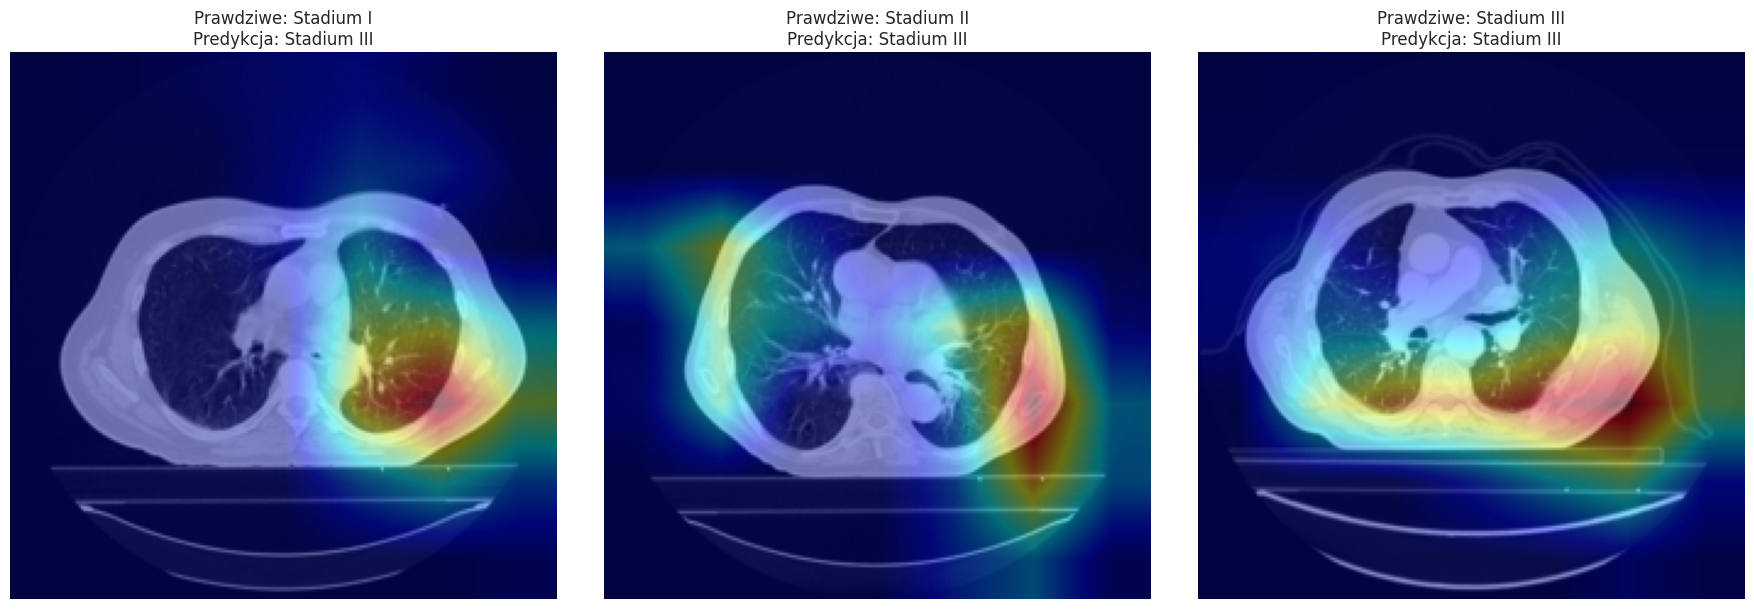

In [ ]:
def generate_gradcam(model, input_img, clinical_data, target_layer):
    model.eval()

    feature_blobs = []
    gradients = []

    def hook_feature(module, input, output):
        feature_blobs.append(output.cpu().data.numpy())

    def hook_gradient(module, grad_input, grad_output):
        gradients.append(grad_output[0].cpu().data.numpy())

    handle_forward = target_layer.register_forward_hook(hook_feature)
    handle_backward = target_layer.register_backward_hook(hook_gradient)

    output = model(input_img, clinical_data)
    _, target_class = torch.max(output, 1)

    model.zero_grad()
    output[0, target_class].backward()

    # Wyznaczanie wag i mapy ciepła
    grads = gradients[0]
    weights = np.mean(grads, axis=(2, 3))[0]
    features = feature_blobs[0][0]

    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))

    handle_forward.remove()
    handle_backward.remove()

    return cam, target_class.item()

def show_gradcam_gallery(model, dataset):
    # Szukamy po jednym przykładzie dla każdego stadium (0, 1, 2)
    indices = []
    for target_label in [0, 1, 2]:
        for i in range(len(dataset)):
            _, _, label = dataset[i]
            if label == target_label:
                indices.append(i)
                break

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    target_names = ['Stadium I', 'Stadium II', 'Stadium III']

    for i, idx in enumerate(indices):
        img_tensor, clinical_tensor, label = dataset[idx]

        input_img = img_tensor.unsqueeze(0).to(device)
        clinical_data = clinical_tensor.unsqueeze(0).to(device)

        heatmap, pred_class = generate_gradcam(model, input_img, clinical_data, model.backbone.layer4)

        img_show = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())

        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
        overlay = 0.6 * img_show + 0.4 * heatmap_color

        axes[i].imshow(overlay)
        axes[i].set_title(f"Prawdziwe: {target_names[label]}\nPredykcja: {target_names[pred_class]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Wywołanie
show_gradcam_gallery(model, val_dataset)

# Optuna


Tutaj celujemy w usprawnienie F1 jako metryki dla slice'ów

In [16]:
def save_callback(study, trial):
    if trial.state.name == "COMPLETE":
        print(f"\n✓ Trial {trial.number} | F1: {trial.value:.4f} | Najlepszy: {study.best_value:.4f}")
        with open('/content/drive/MyDrive/best_optuna_params_CE.json', 'w') as fp:
            json.dump(study.best_params, fp)

In [31]:
EPOCHS_PER_TRIAL = 20

def objective(trial):
    # Zawężone hiperparametry wokół najlepszego ręcznego setupu
    gamma        = trial.suggest_float("gamma",        1.4,   1.6)
    lr_fc        = trial.suggest_float("lr_fc",        8e-4,  2e-3,  log=True)
    lr_layer4    = trial.suggest_float("lr_layer4",    3e-6,  8e-6,  log=True)
    lr_layer3    = trial.suggest_float("lr_layer3",    5e-7,  3e-6,  log=True)
    weight_decay = trial.suggest_float("weight_decay", 5e-4,  3e-3,  log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.35,  0.48)

    model = ResNetHybrid(num_classes=3, dropout_rate=dropout_rate).to(device)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.backbone.layer3.parameters():
        param.requires_grad = True
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    train_labels  = train_dataset.data_frame['merged_label'].values
    class_counts  = np.bincount(train_labels)
    soft_weights  = 1.0 / np.sqrt(class_counts)
    soft_weights  = soft_weights / soft_weights.sum() * 3
    weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

    criterion = FocalLoss(gamma=gamma, weight=weights_tensor)

    optimizer = optim.Adam([
        {'params': model.backbone.layer3.parameters(), 'lr': lr_layer3},
        {'params': model.backbone.layer4.parameters(), 'lr': lr_layer4},
        {'params': model.classifier.parameters(),      'lr': lr_fc}
    ], weight_decay=weight_decay)

    best_trial_f1 = 0.0

    for epoch in range(EPOCHS_PER_TRIAL):
        model.train()
        for inputs, clinical_data, labels in train_loader:
            inputs        = inputs.to(device)
            clinical_data = clinical_data.to(device)
            labels        = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs, clinical_data)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        all_labels, all_preds, all_probs = [], [], []

        with torch.no_grad():
            for inputs, clinical_data, labels in val_loader:
                inputs        = inputs.to(device)
                clinical_data = clinical_data.to(device)

                outputs = model(inputs, clinical_data)
                probs   = torch.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        val_f1 = f1_score(all_labels, all_preds, average='macro')

        try:
            val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        except:
            val_auc = 0.0

        if val_f1 > best_trial_f1:
            best_trial_f1 = val_f1

        print(f"  Trial {trial.number} | E{epoch+1:02} | F1: {val_f1:.4f} | AUC: {val_auc:.4f} | Best F1: {best_trial_f1:.4f}")

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_trial_f1

def save_callback(study, trial):
    if trial.state.name == "COMPLETE":
        print(f"\n✓ Trial {trial.number} | F1: {trial.value:.4f} | Najlepszy: {study.best_value:.4f}")
        with open('/content/drive/MyDrive/best_optuna_params_focal_v2.json', 'w') as fp:
            json.dump(study.best_params, fp, indent=2)

# Nowe study — zawężone parametry
study = optuna.create_study(
    direction="maximize",
    study_name="ResNetHybrid_Focal_224_V2",
    storage="sqlite:////content/drive/MyDrive/optuna_focal_224_V2.db",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

print(f"Triali w bazie: {len(study.trials)}")

study.optimize(
    objective,
    n_trials=20,
    timeout=36000,
    callbacks=[save_callback]
)

print(f"\nNajlepszy F1: {study.best_value:.4f}")
print("Najlepsze parametry:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

with open('/content/drive/MyDrive/best_optuna_params_focal_v2.json', 'w') as fp:
    json.dump(study.best_params, fp, indent=2)
print("\nParametry zapisane do Drive.")

[I 2026-04-25 13:33:49,210] A new study created in RDB with name: ResNetHybrid_Focal_224_V2


Triali w bazie: 0
  Trial 0 | E01 | F1: 0.2879 | AUC: 0.6871 | Best F1: 0.2879
  Trial 0 | E02 | F1: 0.4051 | AUC: 0.7020 | Best F1: 0.4051
  Trial 0 | E03 | F1: 0.5051 | AUC: 0.7397 | Best F1: 0.5051
  Trial 0 | E04 | F1: 0.4035 | AUC: 0.6744 | Best F1: 0.5051
  Trial 0 | E05 | F1: 0.4604 | AUC: 0.6876 | Best F1: 0.5051
  Trial 0 | E06 | F1: 0.4742 | AUC: 0.7121 | Best F1: 0.5051
  Trial 0 | E07 | F1: 0.4624 | AUC: 0.6987 | Best F1: 0.5051
  Trial 0 | E08 | F1: 0.4315 | AUC: 0.7144 | Best F1: 0.5051
  Trial 0 | E09 | F1: 0.4082 | AUC: 0.6816 | Best F1: 0.5051
  Trial 0 | E10 | F1: 0.4797 | AUC: 0.7002 | Best F1: 0.5051
  Trial 0 | E11 | F1: 0.4394 | AUC: 0.6924 | Best F1: 0.5051
  Trial 0 | E12 | F1: 0.4786 | AUC: 0.7156 | Best F1: 0.5051
  Trial 0 | E13 | F1: 0.4706 | AUC: 0.6768 | Best F1: 0.5051
  Trial 0 | E14 | F1: 0.4343 | AUC: 0.6914 | Best F1: 0.5051
  Trial 0 | E15 | F1: 0.4162 | AUC: 0.6671 | Best F1: 0.5051
  Trial 0 | E16 | F1: 0.4256 | AUC: 0.6760 | Best F1: 0.5051
  Tria

[I 2026-04-25 13:42:49,834] Trial 0 finished with value: 0.5050927071620924 and parameters: {'gamma': 1.5614326564818974, 'lr_fc': 0.0008915402900856748, 'lr_layer4': 6.6135581936588e-06, 'lr_layer3': 9.575457599869632e-07, 'weight_decay': 0.0011504398988593074, 'dropout_rate': 0.4520248480318815}. Best is trial 0 with value: 0.5050927071620924.


  Trial 0 | E20 | F1: 0.3914 | AUC: 0.6324 | Best F1: 0.5051

✓ Trial 0 | F1: 0.5051 | Najlepszy: 0.5051
  Trial 1 | E01 | F1: 0.4239 | AUC: 0.7198 | Best F1: 0.4239
  Trial 1 | E02 | F1: 0.4495 | AUC: 0.6613 | Best F1: 0.4495
  Trial 1 | E03 | F1: 0.3640 | AUC: 0.6398 | Best F1: 0.4495
  Trial 1 | E04 | F1: 0.4458 | AUC: 0.6822 | Best F1: 0.4495
  Trial 1 | E05 | F1: 0.4690 | AUC: 0.6995 | Best F1: 0.4690
  Trial 1 | E06 | F1: 0.4744 | AUC: 0.7381 | Best F1: 0.4744
  Trial 1 | E07 | F1: 0.3959 | AUC: 0.6993 | Best F1: 0.4744
  Trial 1 | E08 | F1: 0.4005 | AUC: 0.6910 | Best F1: 0.4744
  Trial 1 | E09 | F1: 0.4366 | AUC: 0.6981 | Best F1: 0.4744
  Trial 1 | E10 | F1: 0.4348 | AUC: 0.6606 | Best F1: 0.4744
  Trial 1 | E11 | F1: 0.4596 | AUC: 0.6681 | Best F1: 0.4744
  Trial 1 | E12 | F1: 0.3547 | AUC: 0.6423 | Best F1: 0.4744
  Trial 1 | E13 | F1: 0.4217 | AUC: 0.6855 | Best F1: 0.4744
  Trial 1 | E14 | F1: 0.3701 | AUC: 0.6591 | Best F1: 0.4744
  Trial 1 | E15 | F1: 0.3882 | AUC: 0.638

[I 2026-04-25 13:51:46,825] Trial 1 finished with value: 0.4744457336477533 and parameters: {'gamma': 1.5553760389440512, 'lr_fc': 0.0012822648934230716, 'lr_layer4': 7.461765892960999e-06, 'lr_layer3': 6.742889794537905e-07, 'weight_decay': 0.0015642543276139227, 'dropout_rate': 0.3725444020189453}. Best is trial 0 with value: 0.5050927071620924.


...

  Trial 17 | E06 | F1: 0.4122 | AUC: 0.6627 | Best F1: 0.4536
  Trial 18 | E01 | F1: 0.3699 | AUC: 0.6754 | Best F1: 0.3699
  Trial 18 | E02 | F1: 0.3221 | AUC: 0.7477 | Best F1: 0.3699
  Trial 18 | E03 | F1: 0.4550 | AUC: 0.7109 | Best F1: 0.4550
  Trial 18 | E04 | F1: 0.3758 | AUC: 0.6511 | Best F1: 0.4550
  Trial 18 | E05 | F1: 0.4129 | AUC: 0.6676 | Best F1: 0.4550


[I 2026-04-25 15:46:41,952] Trial 18 pruned. 


  Trial 18 | E06 | F1: 0.4338 | AUC: 0.6609 | Best F1: 0.4550
  Trial 19 | E01 | F1: 0.4196 | AUC: 0.6811 | Best F1: 0.4196
  Trial 19 | E02 | F1: 0.4063 | AUC: 0.6469 | Best F1: 0.4196
  Trial 19 | E03 | F1: 0.4242 | AUC: 0.6834 | Best F1: 0.4242
  Trial 19 | E04 | F1: 0.4703 | AUC: 0.7201 | Best F1: 0.4703
  Trial 19 | E05 | F1: 0.4352 | AUC: 0.6509 | Best F1: 0.4703
  Trial 19 | E06 | F1: 0.4837 | AUC: 0.7046 | Best F1: 0.4837
  Trial 19 | E07 | F1: 0.3903 | AUC: 0.6391 | Best F1: 0.4837
  Trial 19 | E08 | F1: 0.4072 | AUC: 0.6673 | Best F1: 0.4837
  Trial 19 | E09 | F1: 0.3976 | AUC: 0.7103 | Best F1: 0.4837
  Trial 19 | E10 | F1: 0.4304 | AUC: 0.6674 | Best F1: 0.4837
  Trial 19 | E11 | F1: 0.4338 | AUC: 0.6924 | Best F1: 0.4837
  Trial 19 | E12 | F1: 0.4393 | AUC: 0.7008 | Best F1: 0.4837
  Trial 19 | E13 | F1: 0.4229 | AUC: 0.6832 | Best F1: 0.4837
  Trial 19 | E14 | F1: 0.4624 | AUC: 0.6703 | Best F1: 0.4837
  Trial 19 | E15 | F1: 0.4197 | AUC: 0.6687 | Best F1: 0.4837
  Trial 

[I 2026-04-25 15:55:38,778] Trial 19 finished with value: 0.4836543293632845 and parameters: {'gamma': 1.4509242512996912, 'lr_fc': 0.0011981742623052608, 'lr_layer4': 4.27354559964486e-06, 'lr_layer3': 1.624644710212401e-06, 'weight_decay': 0.0024589779041379097, 'dropout_rate': 0.4525445125507988}. Best is trial 9 with value: 0.5164713064713065.


  Trial 19 | E20 | F1: 0.4181 | AUC: 0.6426 | Best F1: 0.4837

✓ Trial 19 | F1: 0.4837 | Najlepszy: 0.5165

Najlepszy F1: 0.5165
Najlepsze parametry:
  gamma: 1.464454330658675
  lr_fc: 0.0016277238442850828
  lr_layer4: 3.487672852266998e-06
  lr_layer3: 1.0827177652793989e-06
  weight_decay: 0.001654204339636278
  dropout_rate: 0.4695673908227094

Parametry zapisane do Drive.


Params warte uwagi:

Załadowanie danych

In [18]:
# Sprawdź aktualny stan
print(f"Triali w bazie: {len(study.trials)}")
print(f"Rekord: {study.best_value:.4f}")
print(f"Najlepsze parametry (trial {study.best_trial.number}):")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Zapisz parametry do JSON na wszelki wypadek
import json
with open('/content/drive/MyDrive/best_optuna_params.json', 'w') as fp:
    json.dump(study.best_params, fp, indent=2)
print("\nParametry zapisane do Drive.")

Triali w bazie: 22
Rekord: 0.5216
Najlepsze parametry (trial 12):
  gamma: 1.2042800601065258
  lr_fc: 0.001539556876246782
  lr_layer4: 4.707965745192217e-06
  lr_layer3: 5.665300946546991e-07
  weight_decay: 0.0010544694882391081
  dropout_rate: 0.4365067552988919

Parametry zapisane do Drive.


Finałowy trening oraz soft-voting

In [41]:
# FINALNY TRENING — ResNetHybrid z best_params z Optuny

best_params = study.best_trial.params
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

print(f"Urządzenie: {device}")
print(f"Najlepsze parametry z Optuny: {best_params}\n")

model = ResNetHybrid(
    num_classes=3,
    dropout_rate=best_params.get('dropout_rate', 0.4)
).to(device)

for param in model.parameters():
    param.requires_grad = False
for param in model.backbone.layer3.parameters():
    param.requires_grad = True
for param in model.backbone.layer4.parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

train_labels = train_dataset.data_frame['merged_label'].values
class_counts = np.bincount(train_labels)
print(f"Rzeczywista liczba wycinków w klasach (I, II, III): {class_counts}")

class_counts = np.bincount(train_labels)
soft_weights = 1.0 / np.sqrt(class_counts)
soft_weights = soft_weights / soft_weights.sum() * 3
weights_tensor = torch.tensor(soft_weights, dtype=torch.float32).to(device)

criterion = FocalLoss(gamma=1.5, weight=weights_tensor)

optimizer = optim.Adam([
    {'params': model.backbone.layer3.parameters(), 'lr': 1e-6},
    {'params': model.backbone.layer4.parameters(), 'lr': 5e-6},
    {'params': model.classifier.parameters(),      'lr': 1e-3}  #
], weight_decay=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=4
)

# Zmienne kontrolne
NUM_EPOCHS     = 30
PATIENCE       = 8
best_val_f1  = 0.0
best_val_auc = 0.0
best_model_wts_f1  = copy.deepcopy(model.state_dict())
best_model_wts_auc = copy.deepcopy(model.state_dict())
patience_counter = 0

history = {
    'train_loss': [], 'val_loss': [],
    'train_auc':  [], 'val_auc':  [],
    'train_f1':   [], 'val_f1':   [],
    'train_acc':  [], 'val_acc':  []
}

print(f"{'Epoka':<6} {'T-Loss':<8} {'V-Loss':<8} {'V-AUC':<8} {'V-F1':<7} {'V-Acc':<7} {'Best-AUC':<10} {'Best-F1'}")

for epoch in range(NUM_EPOCHS):

    # Trening
    model.train()
    running_loss = 0.0
    all_labels, all_probs, all_preds = [], [], []

    for inputs, clinical, labels in train_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)
        labels   = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, clinical)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())

    train_loss = running_loss / len(train_loader.dataset)
    train_auc  = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    train_f1   = f1_score(all_labels, all_preds, average='macro')
    train_acc  = accuracy_score(all_labels, all_preds)

    # Walidacja
    model.eval()
    v_loss = 0.0
    v_labels, v_preds, v_probs = [], [], []

    with torch.no_grad():
        for inputs, clinical, labels in val_loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            labels   = labels.to(device)

            outputs = model(inputs, clinical)
            loss    = criterion(outputs, labels)

            v_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            v_labels.extend(labels.cpu().numpy())
            v_preds.extend(preds.cpu().numpy())
            v_probs.extend(probs.cpu().numpy())

    val_loss = v_loss / len(val_loader.dataset)
    val_auc  = roc_auc_score(v_labels, v_probs, multi_class='ovr', average='macro')
    val_f1   = f1_score(v_labels, v_preds, average='macro')
    val_acc  = accuracy_score(v_labels, v_preds)

    # Zapis do historii
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"E{epoch+1:02}   | {train_loss:<8.3f} {val_loss:<8.3f} {val_auc:<8.4f} {val_f1:<7.3f} {val_acc:<7.3f} {best_val_auc:<10.4f} {best_val_f1:.4f}")
    scheduler.step(val_f1)

    # Najlepszy model po F1
    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        best_val_auc   = val_auc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), '/content/best_hybrid_f1_dual.pth')
        patience_counter = 0
        print(f"      ✓ Nowy najlepszy model (F1: {best_val_f1:.4f} | AUC: {best_val_auc:.4f})")
    else:
        patience_counter += 1

    if val_auc > best_val_auc:
      best_val_auc   = val_auc
      best_model_wts_auc = copy.deepcopy(model.state_dict())
      torch.save(model.state_dict(), '/content/best_hybrid_auc_dual.pth')
      print(f"      ✓ Nowy najlepszy model AUC (AUC: {val_auc:.4f} | F1: {val_f1:.4f})")

    # Early Stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping — brak poprawy F1 przez {PATIENCE} epok.")
        break

print(f"Trening zakończony | Najlepszy Val AUC: {best_val_auc:.4f} | Najlepszy Val F1: {best_val_f1:.4f}")

Urządzenie: cuda
Najlepsze parametry z Optuny: {'gamma': 1.464454330658675, 'lr_fc': 0.0016277238442850828, 'lr_layer4': 3.487672852266998e-06, 'lr_layer3': 1.0827177652793989e-06, 'weight_decay': 0.001654204339636278, 'dropout_rate': 0.4695673908227094}

Rzeczywista liczba wycinków w klasach (I, II, III): [ 777  469 3756]
Epoka  T-Loss   V-Loss   V-AUC    V-F1    V-Acc   Best-AUC   Best-F1
E01   | 0.295    0.307    0.6903   0.360   0.466   0.0000     0.0000
      ✓ Nowy najlepszy model (F1: 0.3604 | AUC: 0.6903)
E02   | 0.271    0.318    0.6938   0.304   0.377   0.6903     0.3604
      ✓ Nowy najlepszy model AUC (AUC: 0.6938 | F1: 0.3038)
E03   | 0.252    0.345    0.6661   0.374   0.494   0.6938     0.3604
      ✓ Nowy najlepszy model (F1: 0.3740 | AUC: 0.6661)
E04   | 0.244    0.365    0.6561   0.378   0.492   0.6661     0.3740
      ✓ Nowy najlepszy model (F1: 0.3778 | AUC: 0.6561)
E05   | 0.233    0.319    0.6692   0.451   0.617   0.6561     0.3778
      ✓ Nowy najlepszy model (F1:

Test

Liczba pacjentów w test secie: 60
Rozkład klas: I=13, II=6, III=41

UWAGA: K-fold tylko na test secie — brak data leakage z train/val.
Służy do oceny stabilności wyniku, nie do porównania z benchmarkiem.

─────────────────────────────────────────────────────────────────
Fold   Model    AUC      F1       Acc      I-F1     II-F1    III-F1
─────────────────────────────────────────────────────────────────

Fold 1 — n=12 pacjentów (I=2, II=1, III=9)
  F1       0.9086   0.5222   0.8333   0.6667   0.0000   0.9000
  AUC      0.8344   0.3000   0.7500   0.0000   0.0000   0.9000

Fold 2 — n=12 pacjentów (I=3, II=1, III=8)
  F1       0.9489   0.5630   0.8333   0.8000   0.0000   0.8889
  AUC      0.9014   0.7111   0.7500   0.6667   0.6667   0.8000

Fold 3 — n=12 pacjentów (I=3, II=1, III=8)
  F1       0.6104   0.3926   0.6667   0.4000   0.0000   0.7778
  AUC      0.6084   0.3926   0.6667   0.4000   0.0000   0.7778

Fold 4 — n=12 pacjentów (I=3, II=1, III=8)
  F1       0.4154   0.4474   0.7500   0.5

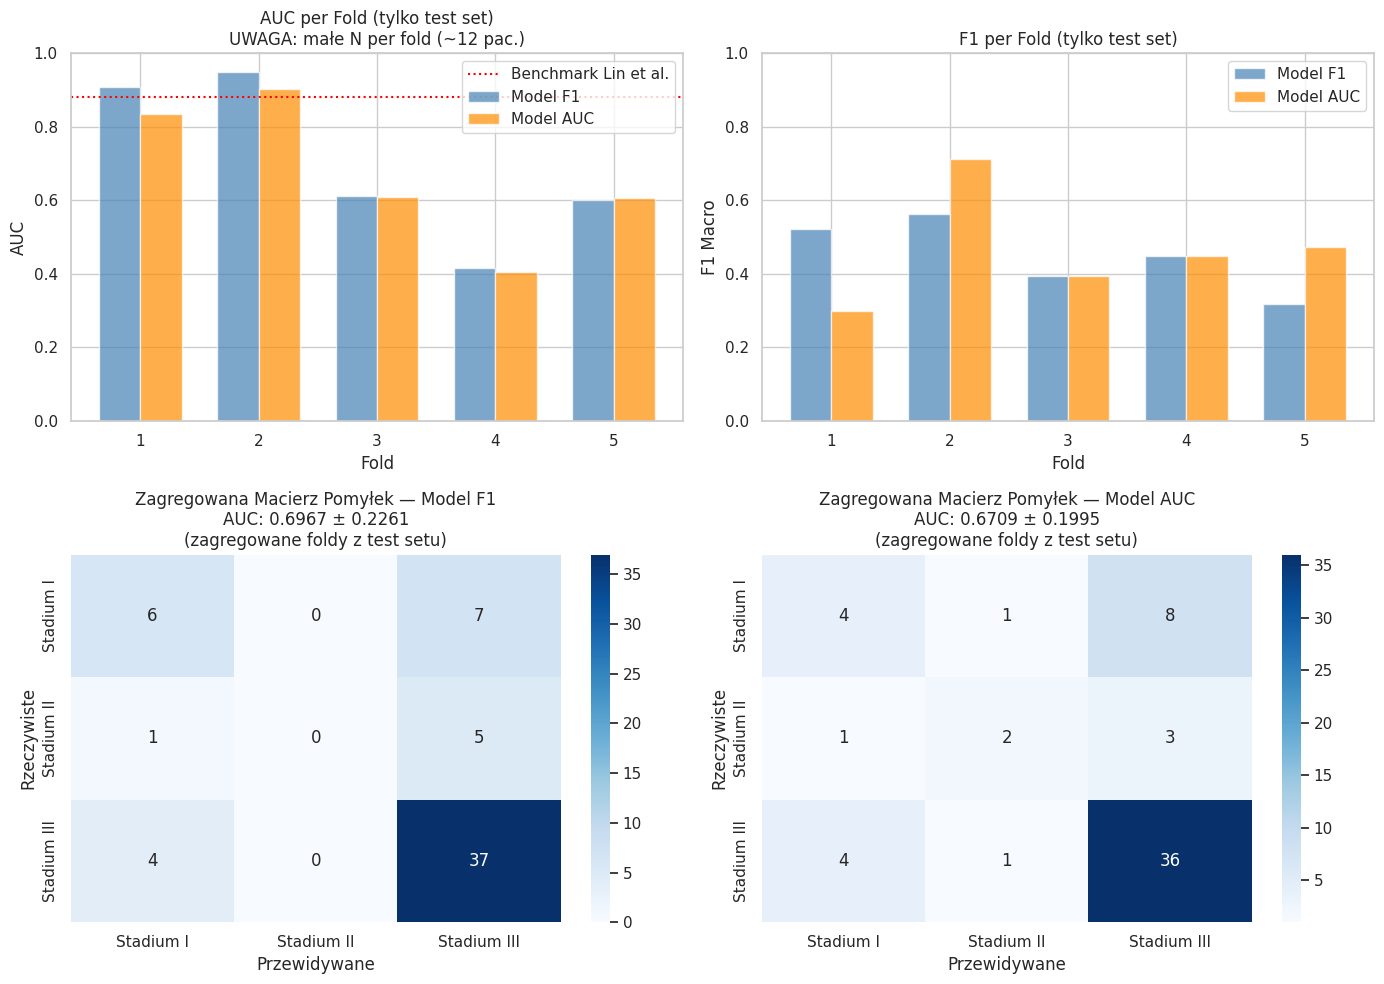


Zagregowany raport klasyfikacji — Model F1:
              precision    recall  f1-score   support

   Stadium I     0.5455    0.4615    0.5000        13
  Stadium II     0.0000    0.0000    0.0000         6
 Stadium III     0.7551    0.9024    0.8222        41

    accuracy                         0.7167        60
   macro avg     0.4335    0.4547    0.4407        60
weighted avg     0.6342    0.7167    0.6702        60


Zagregowany raport klasyfikacji — Model AUC:
              precision    recall  f1-score   support

   Stadium I     0.4444    0.3077    0.3636        13
  Stadium II     0.5000    0.3333    0.4000         6
 Stadium III     0.7660    0.8780    0.8182        41

    accuracy                         0.7000        60
   macro avg     0.5701    0.5064    0.5273        60
weighted avg     0.6697    0.7000    0.6779        60



In [42]:
# Ewaluacja na zbiorze testowym z K-Fold

def load_model(path):
    m = ResNetHybrid(
        num_classes=3,
        dropout_rate=best_params.get('dropout_rate', 0.4)
    ).to(device)
    m.load_state_dict(torch.load(path))
    m.eval()
    return m

models_to_eval = {
    'F1':  load_model('/content/best_hybrid_f1_dual.pth'),
    'AUC': load_model('/content/best_hybrid_auc_dual.pth'),
}

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
N_SPLITS = 5

df_test_patches = test_dataset.data_frame.copy()

df_test_patients = (
    df_test_patches
    .groupby('patient_id')['merged_label']
    .first()
    .reset_index()
)

patient_ids    = df_test_patients['patient_id'].values
patient_labels = df_test_patients['merged_label'].values

print(f"Liczba pacjentów w test secie: {len(patient_ids)}")
print(f"Rozkład klas: I={np.sum(patient_labels==0)}, "
      f"II={np.sum(patient_labels==1)}, "
      f"III={np.sum(patient_labels==2)}")
print(f"\nUWAGA: K-fold tylko na test secie — brak data leakage z train/val.")
print(f"Służy do oceny stabilności wyniku, nie do porównania z benchmarkiem.")

def evaluate_fold(model, df_fold):
    fold_dataset = LungCancerHybridDataset.__new__(LungCancerHybridDataset)
    fold_dataset.data_frame = df_fold.reset_index(drop=True)
    fold_dataset.root_dir   = IMG_DIR_COLAB
    fold_dataset.transform  = val_test_transforms

    fold_loader = DataLoader(
        fold_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2
    )

    fold_labels, fold_probs = [], []
    with torch.no_grad():
        for inputs, clinical, labels in fold_loader:
            inputs   = inputs.to(device)
            clinical = clinical.to(device)
            outputs  = model(inputs, clinical)
            probs    = torch.softmax(outputs, dim=1)

            fold_labels.extend(labels.cpu().numpy())
            fold_probs.extend(probs.cpu().numpy())

    df_fold = df_fold.copy()
    df_fold['prob_I']     = [p[0] for p in fold_probs]
    df_fold['prob_II']    = [p[1] for p in fold_probs]
    df_fold['prob_III']   = [p[2] for p in fold_probs]
    df_fold['true_label'] = fold_labels

    patient_agg = (
        df_fold.groupby('patient_id')[['prob_I', 'prob_II', 'prob_III', 'true_label']]
        .agg({'prob_I': 'mean', 'prob_II': 'mean',
              'prob_III': 'mean', 'true_label': 'first'})
        .reset_index()
    )

    probs_arr = patient_agg[['prob_I', 'prob_II', 'prob_III']].values
    preds_arr = np.argmax(probs_arr, axis=1)
    true_arr  = patient_agg['true_label'].values

    present_classes = np.unique(true_arr)
    if len(present_classes) < 2:
        return None

    try:
        fold_auc = roc_auc_score(
            true_arr, probs_arr,
            multi_class='ovr', average='macro',
            labels=[0, 1, 2]
        )
    except ValueError:
        fold_auc = float('nan')

    fold_f1      = f1_score(true_arr, preds_arr, average='macro', labels=[0,1,2], zero_division=0)
    fold_acc     = accuracy_score(true_arr, preds_arr)
    per_class_f1 = f1_score(true_arr, preds_arr, average=None, labels=[0,1,2], zero_division=0)

    return {
        'auc':    fold_auc,
        'f1':     fold_f1,
        'acc':    fold_acc,
        'f1_I':   per_class_f1[0],
        'f1_II':  per_class_f1[1],
        'f1_III': per_class_f1[2],
        'n_I':    int(np.sum(true_arr == 0)),
        'n_II':   int(np.sum(true_arr == 1)),
        'n_III':  int(np.sum(true_arr == 2)),
        'true':   true_arr,
        'probs':  probs_arr,
    }

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

all_results = {name: [] for name in models_to_eval}
all_true    = {name: [] for name in models_to_eval}
all_probs   = {name: [] for name in models_to_eval}

print(f"\n{'─'*65}")
print(f"{'Fold':<6} {'Model':<8} {'AUC':<8} {'F1':<8} {'Acc':<8} "
      f"{'I-F1':<8} {'II-F1':<8} {'III-F1'}")
print(f"{'─'*65}")

for fold, (_, test_idx) in enumerate(skf.split(patient_ids, patient_labels)):
    test_patients = set(patient_ids[test_idx])
    df_fold = df_test_patches[
        df_test_patches['patient_id'].isin(test_patients)
    ].copy()

    n_I   = np.sum(patient_labels[test_idx] == 0)
    n_II  = np.sum(patient_labels[test_idx] == 1)
    n_III = np.sum(patient_labels[test_idx] == 2)

    print(f"\nFold {fold+1} — n={len(test_patients)} pacjentów "
          f"(I={n_I}, II={n_II}, III={n_III})")

    for name, model in models_to_eval.items():
        res = evaluate_fold(model, df_fold)

        if res is None:
            print(f"  {name:<8} POMINIĘTY — za mało klas w foldzie")
            continue

        res['fold'] = fold + 1
        all_results[name].append(res)
        all_true[name].extend(res['true'])
        all_probs[name].extend(res['probs'])

        print(f"  {name:<8} {res['auc']:<8.4f} {res['f1']:<8.4f} "
              f"{res['acc']:<8.4f} {res['f1_I']:<8.4f} "
              f"{res['f1_II']:<8.4f} {res['f1_III']:.4f}")

# Podsumowanie
print(f"\n{'═'*65}")
print("PODSUMOWANIE K-FOLD NA TEST SECIE (Patient Level, Mean Pooling)")
print("UWAGA: Wyniki służą ocenie stabilności, nie porównaniu z benchmarkiem")
print(f"{'═'*65}")

summary = {}
for name in models_to_eval:
    if not all_results[name]:
        continue
    df_res = pd.DataFrame(all_results[name])
    summary[name] = df_res

    valid = df_res['auc'].dropna()
    print(f"\nModel selekcjonowany po {name} "
          f"({len(valid)}/{N_SPLITS} foldów z wynikiem):")
    for metric in ['auc', 'f1', 'acc', 'f1_I', 'f1_II', 'f1_III']:
        vals = df_res[metric].dropna()
        print(f"  {metric.upper():<10}: {vals.mean():.4f} ± {vals.std():.4f}")

# Wynik referencyjny — pełny test set bez k-fold
print(f"\n{'─'*65}")
print("WYNIK REFERENCYJNY — pełny test set:")
for name, model in models_to_eval.items():
    res_full = evaluate_fold(model, df_test_patches)
    if res_full:
        print(f"  Model {name}: AUC={res_full['auc']:.4f} | "
              f"F1={res_full['f1']:.4f} | Acc={res_full['acc']:.4f}")

# Wizualizacje
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'F1': 'steelblue', 'AUC': 'darkorange'}
x = np.arange(1, N_SPLITS + 1)
width = 0.35

# AUC per fold
ax = axes[0, 0]
for i, (name, color) in enumerate(colors.items()):
    aucs = [r['auc'] for r in all_results[name]]
    ax.bar(x + i * width - width/2, aucs, width,
           color=color, alpha=0.7, label=f'Model {name}')
ax.axhline(0.881, color='red', linestyle=':', label='Benchmark Lin et al.')
ax.set_xlabel('Fold')
ax.set_ylabel('AUC')
ax.set_title('AUC per Fold (tylko test set)\nUWAGA: małe N per fold (~12 pac.)')
ax.set_xticks(x)
ax.legend()
ax.set_ylim(0, 1)

# F1 per fold
ax = axes[0, 1]
for i, (name, color) in enumerate(colors.items()):
    f1s = [r['f1'] for r in all_results[name]]
    ax.bar(x + i * width - width/2, f1s, width,
           color=color, alpha=0.7, label=f'Model {name}')
ax.set_xlabel('Fold')
ax.set_ylabel('F1 Macro')
ax.set_title('F1 per Fold (tylko test set)')
ax.set_xticks(x)
ax.legend()
ax.set_ylim(0, 1)

# Macierze pomyłek — zagregowane ze wszystkich foldów
for col, name in enumerate(['F1', 'AUC']):
    ax = axes[1, col]
    if not all_true[name]:
        ax.set_visible(False)
        continue

    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    preds_arr = np.argmax(probs_arr, axis=1)

    cm = confusion_matrix(true_arr, preds_arr, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names, ax=ax)
    ax.set_xlabel('Przewidywane')
    ax.set_ylabel('Rzeczywiste')

    mean_auc = pd.DataFrame(all_results[name])['auc'].mean()
    std_auc  = pd.DataFrame(all_results[name])['auc'].std()
    ax.set_title(f'Zagregowana Macierz Pomyłek — Model {name}\n'
                 f'AUC: {mean_auc:.4f} ± {std_auc:.4f}\n'
                 f'(zagregowane foldy z test setu)')

plt.tight_layout()
plt.savefig('/content/kfold_testset_focal.png', dpi=300)
plt.show()

# Raport klasyfikacji
for name in models_to_eval:
    if not all_true[name]:
        continue
    true_arr  = np.array(all_true[name])
    probs_arr = np.array(all_probs[name])
    preds_arr = np.argmax(probs_arr, axis=1)
    print(f"\nZagregowany raport klasyfikacji — Model {name}:")
    print(classification_report(true_arr, preds_arr,
                                 target_names=target_names,
                                 digits=4, zero_division=0))

Wyniki soft-voting na zbiorze testowym
(Agregacja 2D -> 3D za pomocą Soft Voting)
PATIENT AUC: 0.7023 (Wynik referencyjny z publikacji: 0.881)
PATIENT ACC: 0.7167
              precision    recall  f1-score   support

   Stadium I       0.55      0.46      0.50        13
  Stadium II       0.00      0.00      0.00         6
 Stadium III       0.76      0.90      0.82        41

    accuracy                           0.72        60
   macro avg       0.43      0.45      0.44        60
weighted avg       0.63      0.72      0.67        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


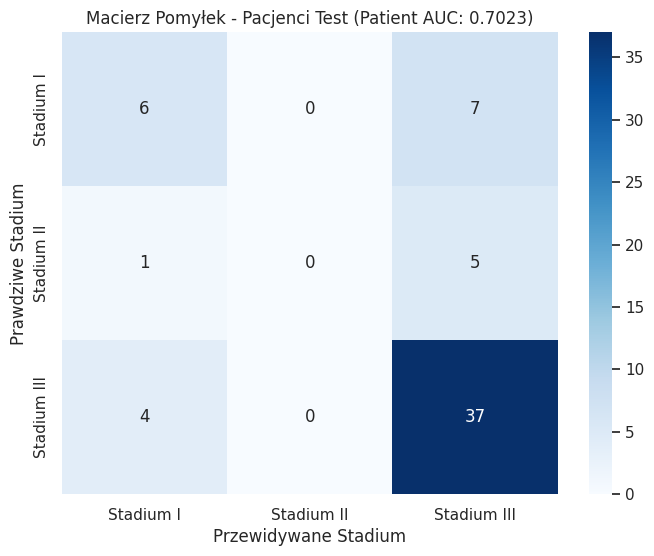

In [44]:
# Soft-voting na poziomie pacjentów — zbiór testowy

# Predykcje na test_loader
model_auc = models_to_eval['F1']
model_auc.eval()

test_preds_raw, test_labels_raw, test_probs_raw = [], [], []

with torch.no_grad():
    for inputs, clinical_data, labels in test_loader:
        inputs        = inputs.to(device)
        clinical_data = clinical_data.to(device)

        outputs = model_auc(inputs, clinical_data)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        test_preds_raw.extend(preds.cpu().numpy())
        test_labels_raw.extend(labels.cpu().numpy())
        test_probs_raw.extend(probs.cpu().numpy())

# Soft-voting
df_test_results = test_dataset.data_frame.copy()

df_test_results['prob_I']     = [p[0] for p in test_probs_raw]
df_test_results['prob_II']    = [p[1] for p in test_probs_raw]
df_test_results['prob_III']   = [p[2] for p in test_probs_raw]
df_test_results['true_label'] = test_labels_raw

patient_level_df = df_test_results.groupby('patient_id').agg({
    'prob_I':     'mean',
    'prob_II':    'mean',
    'prob_III':   'mean',
    'true_label': 'first'
}).reset_index()

patient_probs = patient_level_df[['prob_I', 'prob_II', 'prob_III']].values
patient_preds = np.argmax(patient_probs, axis=1)
patient_true  = patient_level_df['true_label'].values

patient_acc = accuracy_score(patient_true, patient_preds)
patient_auc = roc_auc_score(patient_true, patient_probs, multi_class='ovr', average='macro')

print("Wyniki soft-voting na zbiorze testowym")
print("(Agregacja 2D -> 3D za pomocą Soft Voting)")
print(f"PATIENT AUC: {patient_auc:.4f} (Wynik referencyjny z publikacji: 0.881)")
print(f"PATIENT ACC: {patient_acc:.4f}")
print(classification_report(patient_true, patient_preds, target_names=target_names))

cm_patient = confusion_matrix(patient_true, patient_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_patient, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Macierz Pomyłek - Pacjenci Test (Patient AUC: {patient_auc:.4f})')
plt.ylabel('Prawdziwe Stadium')
plt.xlabel('Przewidywane Stadium')
plt.savefig('/content/softvoting_test_auc.png', dpi=300)
plt.show()

Wykresy dla zbioru TRAIN i VAL

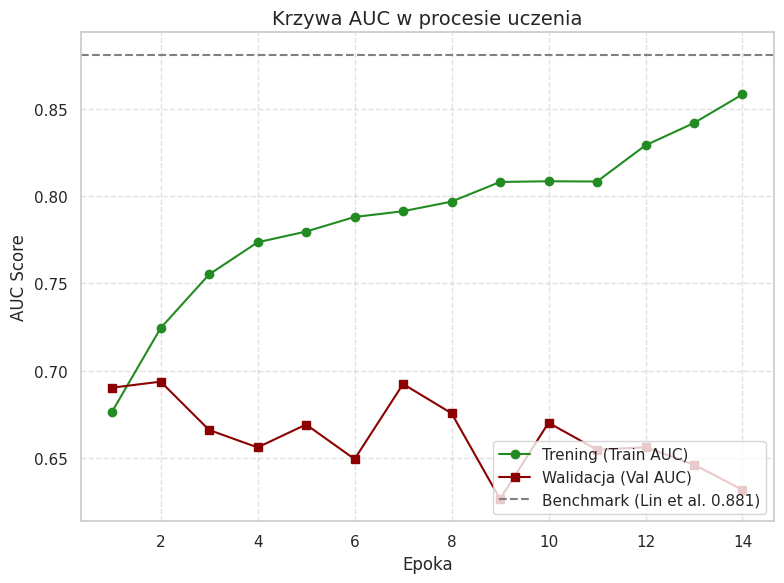

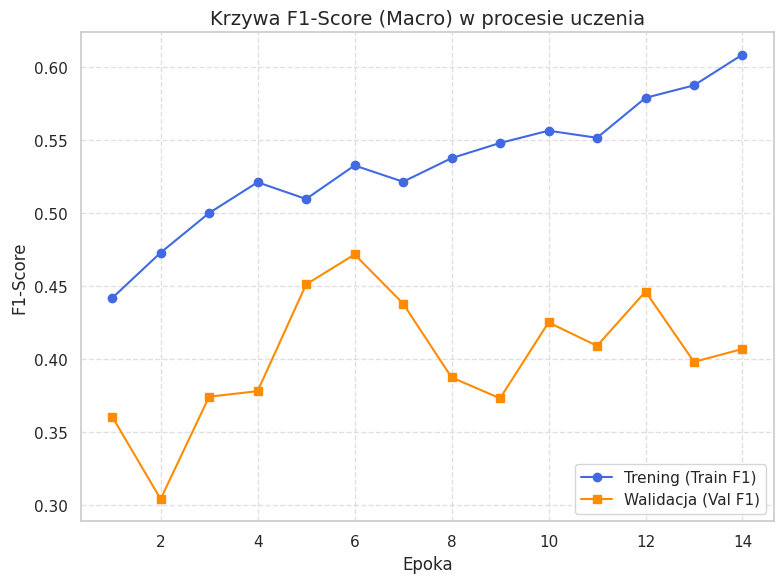

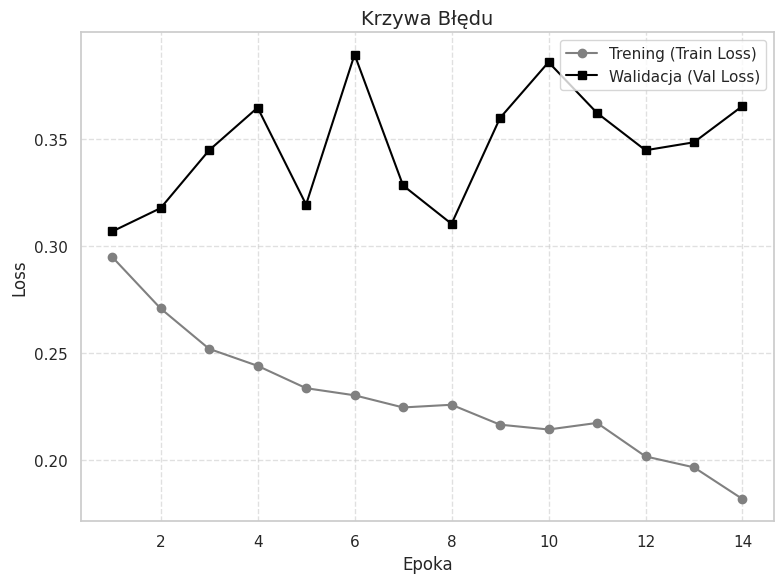

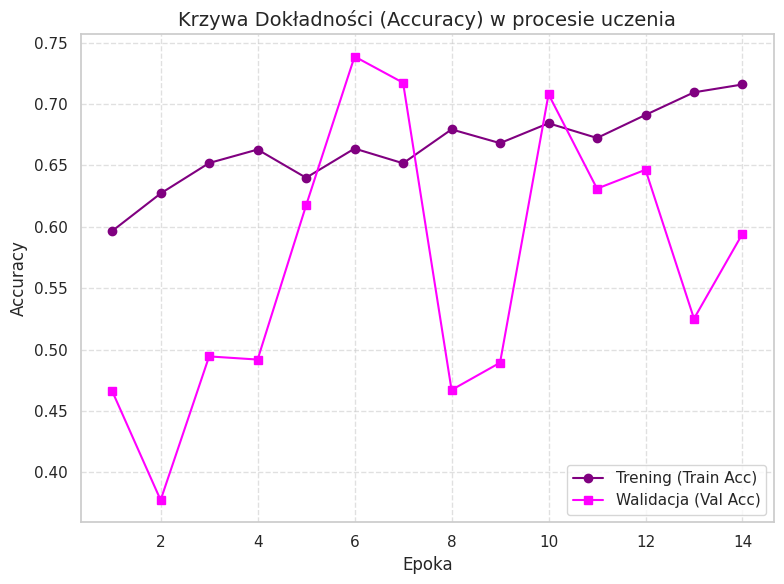

In [45]:
epochs_range = range(1, len(history['train_loss']) + 1)

# AUC
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_auc'], label='Trening (Train AUC)', marker='o', color='forestgreen')
plt.plot(epochs_range, history['val_auc'], label='Walidacja (Val AUC)', marker='s', color='darkred')
plt.axhline(y=0.881, color='gray', linestyle='--', label='Benchmark (Lin et al. 0.881)')
plt.title('Krzywa AUC w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_auc_focal.png', dpi=300, bbox_inches='tight')
plt.show()

# F1-Score
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_f1'], label='Trening (Train F1)', marker='o', color='royalblue')
plt.plot(epochs_range, history['val_f1'], label='Walidacja (Val F1)', marker='s', color='darkorange')
plt.title('Krzywa F1-Score (Macro) w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_f1_focal.png', dpi=300, bbox_inches='tight')
plt.show()

# Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_loss'], label='Trening (Train Loss)', marker='o', color='gray')
plt.plot(epochs_range, history['val_loss'], label='Walidacja (Val Loss)', marker='s', color='black')
plt.title('Krzywa Błędu', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_loss_focal.png', dpi=300, bbox_inches='tight')
plt.show()

# Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, history['train_acc'], label='Trening (Train Acc)', marker='o', color='purple')
plt.plot(epochs_range, history['val_acc'], label='Walidacja (Val Acc)', marker='s', color='magenta')
plt.title('Krzywa Dokładności (Accuracy) w procesie uczenia', fontsize=14)
plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/final_hybrid_accuracy_focal.png', dpi=300, bbox_inches='tight')
plt.show()

Krzywe ROC

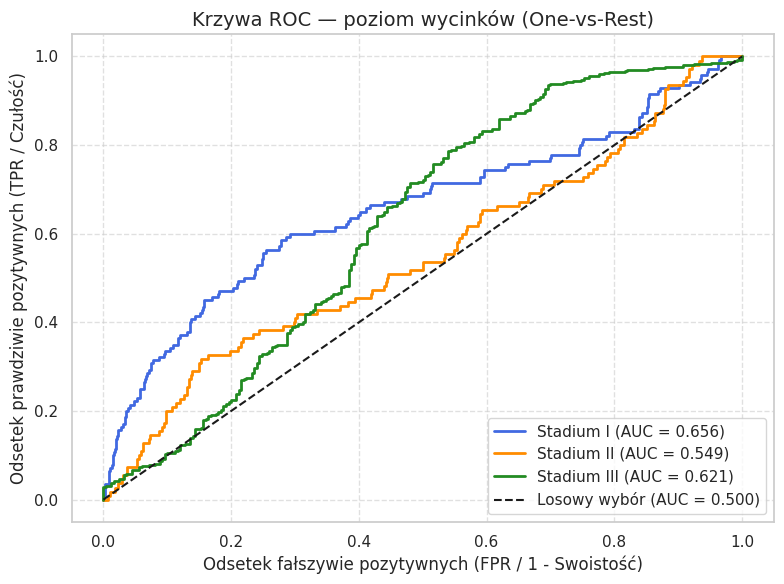

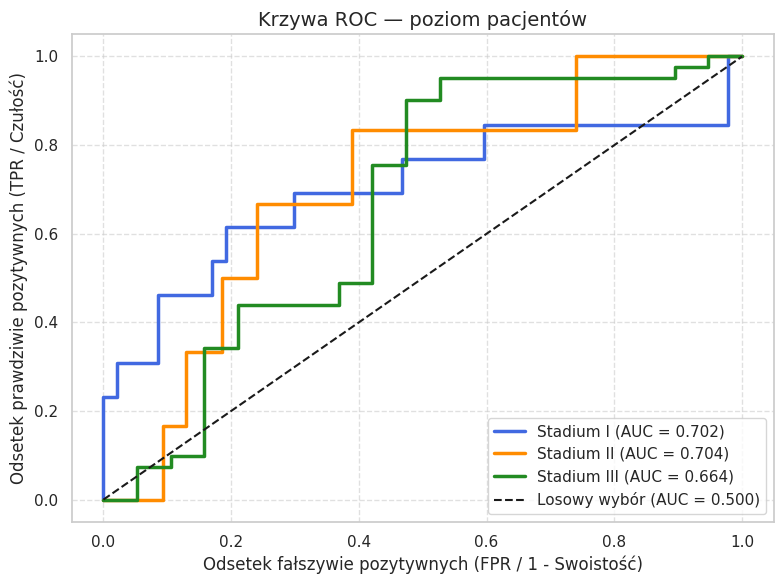

In [49]:
# ==========================================
# KOMÓRKA: KRZYWE ROC DLA PEŁNEGO ZBIORU TESTOWEGO
# ==========================================
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
target_names = ['Stadium I', 'Stadium II', 'Stadium III']
classes = [0, 1, 2]

# 1. Załaduj wybrany model do ewaluacji (np. po samplerze)
# ZMIEŃ ŚCIEŻKĘ jeśli chcesz przetestować inny plik .pth
MODEL_PATH = '/content/best_hybrid_f1_dual.pth'

model = ResNetHybrid(
    num_classes=3,
    dropout_rate=best_params.get('dropout_rate', 0.4)
).to(device)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# 2. Przeprowadź predykcję na całym loaderze testowym
test_labels, test_probs = [], []

with torch.no_grad():
    for inputs, clinical, labels in test_loader:
        inputs   = inputs.to(device)
        clinical = clinical.to(device)
        outputs  = model(inputs, clinical)
        probs    = torch.softmax(outputs, dim=1)

        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)

# 3. Agregacja do poziomu pacjenta (Top-7 Pooling)
df_test = test_dataset.data_frame.copy()
df_test['prob_I']     = test_probs[:, 0]
df_test['prob_II']    = test_probs[:, 1]
df_test['prob_III']   = test_probs[:, 2]
df_test['true_label'] = test_labels

def get_top_k_mean(group, k=7):
    pk_I   = group['prob_I'].nlargest(k).mean()
    pk_II  = group['prob_II'].nlargest(k).mean()
    pk_III = group['prob_III'].nlargest(k).mean()
    total  = pk_I + pk_II + pk_III
    return pd.Series({
        'final_prob_I':   pk_I / total,
        'final_prob_II':  pk_II / total,
        'final_prob_III': pk_III / total,
        'true_label':     group['true_label'].iloc[0]
    })

patient_level_df = df_test.groupby('patient_id').apply(
    get_top_k_mean, include_groups=False
).reset_index()

patient_probs_arr = patient_level_df[['final_prob_I', 'final_prob_II', 'final_prob_III']].values
patient_true      = patient_level_df['true_label'].values

# ==========================================
# RYSOWANIE WYKRESÓW ROC
# ==========================================

# Rysowanie 1: Krzywe ROC na poziomie wycinków (Slices)
y_true_bin_slices = label_binarize(test_labels, classes=classes)

plt.figure(figsize=(8, 6))
colors = ['royalblue', 'darkorange', 'forestgreen']

for i, (cls_name, color) in enumerate(zip(target_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin_slices[:, i], test_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{cls_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Losowy wybór (AUC = 0.500)')
plt.xlabel('Odsetek fałszywie pozytywnych (FPR / 1 - Swoistość)', fontsize=12)
plt.ylabel('Odsetek prawdziwie pozytywnych (TPR / Czułość)', fontsize=12)
plt.title('Krzywa ROC — poziom wycinków (One-vs-Rest)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/roc_curve_slices_focal.png', dpi=300)
plt.show()

# Rysowanie 2: Krzywe ROC na poziomie pacjentów (Patient Level)
y_true_bin_patient = label_binarize(patient_true, classes=classes)

plt.figure(figsize=(8, 6))

for i, (cls_name, color) in enumerate(zip(target_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin_patient[:, i], patient_probs_arr[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{cls_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Losowy wybór (AUC = 0.500)')
plt.xlabel('Odsetek fałszywie pozytywnych (FPR / 1 - Swoistość)', fontsize=12)
plt.ylabel('Odsetek prawdziwie pozytywnych (TPR / Czułość)', fontsize=12)
plt.title(f'Krzywa ROC — poziom pacjentów', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('/content/roc_curve_patients_focal.png', dpi=300)
plt.show()

Grad-cam

Znaleziono przykłady dla klas: [1, 2, 0]


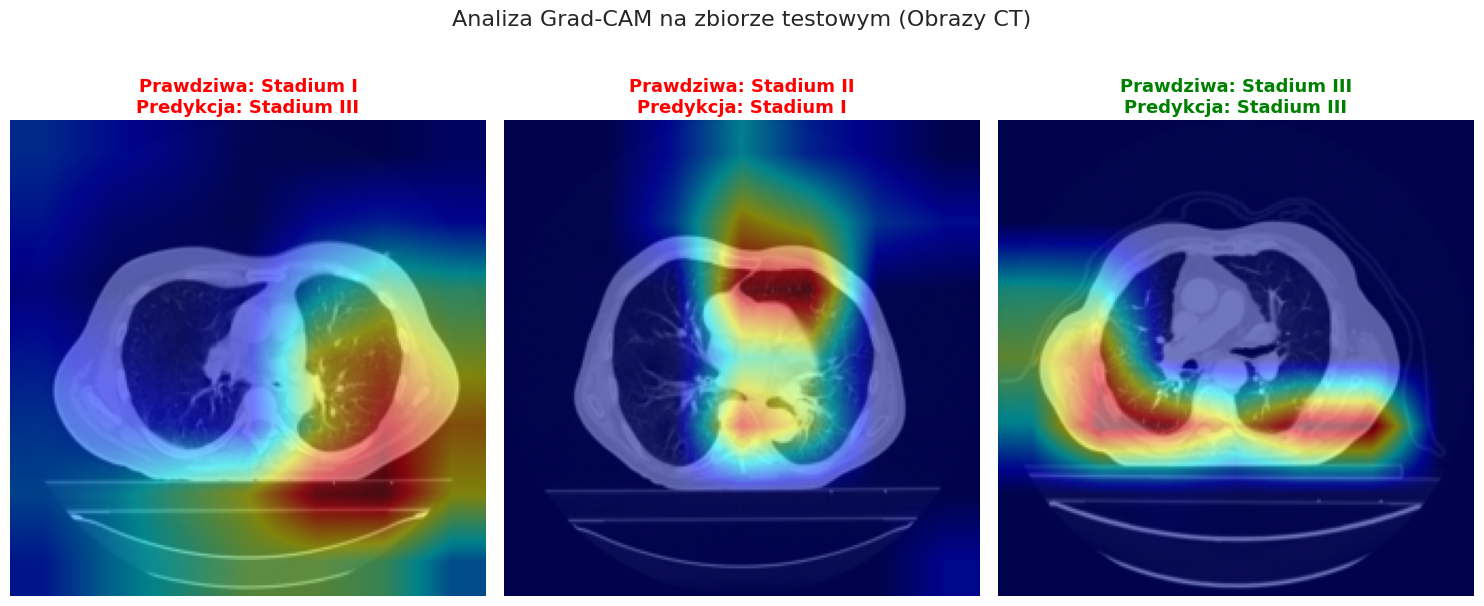

In [48]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


class HybridModelWrapper(torch.nn.Module):
    def __init__(self, model, clinical_data):
        super(HybridModelWrapper, self).__init__()
        self.model = model
        self.clinical_data = clinical_data

    def forward(self, x):
        return self.model(x, self.clinical_data)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

target_layers = [model.backbone.layer4[-1]]
target_names = ['Stadium I', 'Stadium II', 'Stadium III']

# --- NOWY FRAGMENT: Pobieranie po jednym przykładzie dla każdej klasy ---
examples = {}

# Upewnij się, że używasz odpowiedniego loadera (np. test_loader lub val_loader)
for inputs, clinical, labels in val_loader: # ZMIEŃ na test_loader, jeśli masz
    for i in range(len(labels)):
        class_idx = labels[i].item()

        # Jeśli jeszcze nie mamy przykładu dla tej klasy, zapisujemy go
        if class_idx not in examples:
            examples[class_idx] = (inputs[i].detach(), clinical[i].detach())

        # Przerywamy, gdy mamy już po jednym przykładzie dla wszystkich 3 klas (0, 1, 2)
        if len(examples) == 3:
            break
    if len(examples) == 3:
        break

print(f"Znaleziono przykłady dla klas: {list(examples.keys())}")
# -------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Analiza Grad-CAM na zbiorze testowym (Obrazy CT)', fontsize=16, y=1.05)

for class_idx in range(3):
    img_tensor, clin_tensor = examples[class_idx]

    img_tensor = img_tensor.unsqueeze(0).to(device)
    clin_tensor = clin_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor, clin_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()

    wrapped_model = HybridModelWrapper(model, clin_tensor)

    cam = GradCAM(model=wrapped_model, target_layers=target_layers)

    targets = [ClassifierOutputTarget(class_idx)]

    # Generowanie mapy ciepła
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    rgb_img = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min()) # Skalowanie 0-1

    # Nałożenie mapy ciepła na oryginalny obraz
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    ax = axes[class_idx]
    ax.imshow(cam_image)

    # Zmiana koloru tytułu: Zielony jeśli trafił, Czerwony jeśli się pomylił
    color = 'green' if class_idx == pred_idx else 'red'

    ax.set_title(f"Prawdziwa: {target_names[class_idx]}\nPredykcja: {target_names[pred_idx]}",
                 fontsize=13, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/final_hybrid_gradcam_test_dual.png', dpi=300, bbox_inches='tight')
plt.show()

Kalibracja progów

In [51]:

print("Pobieranie predykcji dla zbioru val...")
df_val_patches = val_dataset.data_frame.copy()
val_results = evaluate_fold(models_to_eval['F1'], df_val_patches)

val_probs = val_results['probs']
val_true = val_results['true']

print("Pobieranie predykcji dla zbioru test...")
test_results = evaluate_fold(models_to_eval['F1'], df_test_patches)

test_probs = test_results['probs']
test_true = test_results['true']


best_f1 = 0.0
best_thresholds = [1.0, 1.0, 1.0]
thresholds_range = np.arange(0.1, 1.05, 0.05)

print("\n Kalibracja progów na zbiorze WALIDACYJNYM...\n")

for t0 in thresholds_range:
    for t1 in thresholds_range:
        current_thresholds = np.array([t0, t1, 1.0])

        # Optymalizujemy TYLKO na podstawie zbioru walidacyjnego
        adjusted_probs = val_probs / current_thresholds
        preds = np.argmax(adjusted_probs, axis=1)

        f1 = f1_score(val_true, preds, average='macro', zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_thresholds = current_thresholds

print(f"naleziono optymalne progi (nie widząc zbioru testowego)!")
print(f"   Próg dla Stadium I:   {best_thresholds[0]:.2f}")
print(f"   Próg dla Stadium II:  {best_thresholds[1]:.2f}")
print(f"   Próg dla Stadium III: {best_thresholds[2]:.2f} (Baza)\n")

print("="*55)
print("Ostateczna Ewaluacja na zbiorze TESTOWYM")
print("="*55)

final_adjusted_test_probs = test_probs / best_thresholds
final_test_preds = np.argmax(final_adjusted_test_probs, axis=1)
base_test_preds = np.argmax(test_probs, axis=1)

print("\n--- WYNIK PRZED TUNINGIEM (Standardowy Argmax na teście) ---")
print(classification_report(test_true, base_test_preds, target_names=['Stadium I', 'Stadium II', 'Stadium III'], zero_division=0))

print("\n--- WYNIK PO TUNINGU (Dostosowane progi na teście) ---")
print(classification_report(test_true, final_test_preds, target_names=['Stadium I', 'Stadium II', 'Stadium III'], zero_division=0))

print("\nMacierz pomyłek PO tuningu (na teście):")
print(confusion_matrix(test_true, final_test_preds))

Pobieranie predykcji dla zbioru val...
Pobieranie predykcji dla zbioru test...

 Kalibracja progów na zbiorze WALIDACYJNYM...

naleziono optymalne progi (nie widząc zbioru testowego)!
   Próg dla Stadium I:   1.00
   Próg dla Stadium II:  0.75
   Próg dla Stadium III: 1.00 (Baza)

Ostateczna Ewaluacja na zbiorze TESTOWYM

--- WYNIK PRZED TUNINGIEM (Standardowy Argmax na teście) ---
              precision    recall  f1-score   support

   Stadium I       0.55      0.46      0.50        13
  Stadium II       0.00      0.00      0.00         6
 Stadium III       0.76      0.90      0.82        41

    accuracy                           0.72        60
   macro avg       0.43      0.45      0.44        60
weighted avg       0.63      0.72      0.67        60


--- WYNIK PO TUNINGU (Dostosowane progi na teście) ---
              precision    recall  f1-score   support

   Stadium I       0.55      0.46      0.50        13
  Stadium II       0.00      0.00      0.00         6
 Stadium III   